In [8]:
from pathlib import Path
import kagglehub
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, AutoModel


###Etapa 1: Preparando os dados

In [3]:
#baixa dataset
dataset_path = Path(
    kagglehub.dataset_download("akinduhiman/urban-issues-dataset")
)
print("Dataset baixado em:")
print(dataset_path)

Dataset baixado em:
/Users/llbm/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19


In [16]:
#baixa os arquivos e salva nesse diretório
competition_path = Path(".")

gallery_csv = competition_path / "gallery.csv"
valid_queries_csv = competition_path / "valid_queries.csv"
test_queries_csv = competition_path / "test_queries.csv"
sample_submission_csv = competition_path / "sample_submission.csv"


In [5]:
submission = pd.DataFrame({
    "query_id": test_queries["query_id"],
    "predictions": ""  # depois vamos preencher com os top-10
})

submission.to_csv("submission.csv", index=False)

NameError: name 'test_queries' is not defined

In [18]:
#carrega os dados no notebook
gallery = pd.read_csv(gallery_csv)
valid_queries = pd.read_csv(valid_queries_csv)
test_queries = pd.read_csv(test_queries_csv)


In [7]:
#Visualizar estrutura básica
print("\nGallery:")
display(gallery.head())
print(gallery.shape)

print("\nValidation queries:")
display(valid_queries.head())
print(valid_queries.shape)

print("\nTest queries:")
display(test_queries.head())
print(test_queries.shape)


Gallery:


,gallery_id,image_id,relative_path,label_name
0,g_000000,train__000093_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
1,g_000001,train__000104_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
2,g_000002,train__000107_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
3,g_000003,train__000108_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
4,g_000004,train__000133_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures


(17679, 4)

Validation queries:


,query_id,image_id,relative_path,label_name
0,v_000000,valid__000094_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
1,v_000001,valid__000145_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
2,v_000002,valid__000780_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
3,v_000003,valid__001053_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
4,v_000004,valid__001055_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures


(3775, 4)

Test queries:


,query_id,image_id,relative_path
0,t_000000,test__000100_jpg,Damaged concrete structures/Damaged concrete s...
1,t_000001,test__000144_jpg,Damaged concrete structures/Damaged concrete s...
2,t_000002,test__000791_jpg,Damaged concrete structures/Damaged concrete s...
3,t_000003,test__000795_jpg,Damaged concrete structures/Damaged concrete s...
4,t_000004,test__001062_jpg,Damaged concrete structures/Damaged concrete s...


(3402, 3)


In [19]:
print("\nColunas gallery:", gallery.columns.tolist())
print("Colunas valid_queries:", valid_queries.columns.tolist())
print("Colunas test_queries:", test_queries.columns.tolist())



Colunas gallery: ['gallery_id', 'image_id', 'relative_path', 'label_name']
Colunas valid_queries: ['query_id', 'image_id', 'relative_path', 'label_name']
Colunas test_queries: ['query_id', 'image_id', 'relative_path']


In [8]:
#criar caminho absoluto das imagens
gallery["image_path"] = gallery["relative_path"].apply(
    lambda p: dataset_path / p
)

valid_queries["image_path"] = valid_queries["relative_path"].apply(
    lambda p: dataset_path / p
)

test_queries["image_path"] = test_queries["relative_path"].apply(
    lambda p: dataset_path / p
)

#Verificar se os arquivos existem
gallery["exists"] = gallery["image_path"].apply(lambda p: p.exists())
valid_queries["exists"] = valid_queries["image_path"].apply(lambda p: p.exists())
test_queries["exists"] = test_queries["image_path"].apply(lambda p: p.exists())

print("\nChecagem de arquivos existentes:")
print("Gallery:", gallery["exists"].mean())
print("Validation queries:", valid_queries["exists"].mean())
print("Test queries:", test_queries["exists"].mean())



Checagem de arquivos existentes:
Gallery: 1.0
Validation queries: 1.0
Test queries: 1.0


In [21]:
if "label_name" in gallery.columns:
    print("\nDistribuição de classes na gallery:")
    display(gallery["label_name"].value_counts())

if "label_name" in valid_queries.columns:
    print("\nDistribuição de classes nas queries de validação:")
    display(valid_queries["label_name"].value_counts())


Distribuição de classes na gallery:


label_name
Damaged concrete structures    8684
Potholes and RoadCracks        2575
Garbage                        2455
Graffitti                      1496
DamagedElectricalPoles         1304
FallenTrees                     887
DamagedRoadSigns                233
DeadAnimalsPollution             27
IllegalParking                   18
Name: count, dtype: int64


Distribuição de classes nas queries de validação:


label_name
Damaged concrete structures    1199
Potholes and RoadCracks        1105
Garbage                         524
DamagedElectricalPoles          420
FallenTrees                     276
Graffitti                       205
DamagedRoadSigns                 36
DeadAnimalsPollution              8
IllegalParking                    2
Name: count, dtype: int64

###Etapa 2: Definindo métrica avaliativa

Ideia geral da estratégia avaliativa usada no treino e validação: 
Para cada query, sabemos a classe correta; e para cada gallery_id recuperado, olhamos a classe dele.
Se a classe recuperada for igual à classe da query, conta como relevante. Quanto mais cedo os acertos aparecem no ranking, maior o AP@10.
O MAP@10 é a média do AP@10 de todas as queries.

In [4]:
def apk(actual_label, predicted_labels, k=10):
    # Calcula AP@K para uma única query.
    # actual_label:Classe correta da query.
    # predicted_labels:Lista ordenada com as classes das imagens recuperadas.
    # k:Número máximo de resultados considerados.

    predicted_labels = predicted_labels[:k]

    score = 0.0
    num_hits = 0.0

    for i, pred_label in enumerate(predicted_labels):
        if pred_label == actual_label:
            num_hits += 1.0
            precision_at_i = num_hits / (i + 1.0)
            score += precision_at_i

    # Como pode haver muitas imagens relevantes na galeria,
    # limitamos o denominador ao k.
    return score / k


In [5]:
def mapk(actual_labels, predicted_labels_list, k=10):
    #Calcula MAP@K para várias queries.

    scores = []

    for actual_label, predicted_labels in zip(actual_labels, predicted_labels_list):
        scores.append(apk(actual_label, predicted_labels, k=k))

    return np.mean(scores)

In [6]:
def evaluate_retrieval_mapk(valid_queries, gallery, predictions_df, k=10):
    #Avalia um arquivo/tabela de predições no formato: query_id | predictions

    gallery_label_map = dict(zip(gallery["gallery_id"], gallery["label_name"]))
    query_label_map = dict(zip(valid_queries["query_id"], valid_queries["label_name"]))

    actual_labels = []
    predicted_labels_list = []

    for _, row in predictions_df.iterrows():
        query_id = row["query_id"]
        predicted_gallery_ids = row["predictions"].split()[:k]

        actual_label = query_label_map[query_id]
        predicted_labels = [
            gallery_label_map[gallery_id]
            for gallery_id in predicted_gallery_ids
        ]

        actual_labels.append(actual_label)
        predicted_labels_list.append(predicted_labels)

    return mapk(actual_labels, predicted_labels_list, k=k)

###Etapa 3: Extraindo Embeddings

####3.1: DINOv2

In [12]:
MODEL_NAME = "facebook/dinov2-base"
BATCH_SIZE = 64
NUM_WORKERS = 0
device = "cpu"

In [13]:
#classe para acessar as imagens
class ImageRetrievalDataset(Dataset):
    def __init__(self, df, processor):
        self.df = df.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        return {
            "image": image,
            "idx": idx}

#para juntar várias imagens em um só batch
def collate_fn(batch):
    images = [item["image"] for item in batch]
    indices = [item["idx"] for item in batch]
    #pre processamento esperado pelo Dino (redimensiona, normaliza e converte pra tensor)
    inputs = processor(
        images=images,
        return_tensors="pt")
    return inputs, indices


In [27]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model = model.to(device)
#não treinamos agora, pois queremos usar só como uma lookup table
model.eval()

print("Modelo carregado:", MODEL_NAME)


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Modelo carregado: facebook/dinov2-base


In [12]:
@torch.no_grad()
def extract_embeddings(df, id_col, output_path):
    dataset = ImageRetrievalDataset(df, processor)

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn)

    all_embeddings = []
    all_ids = []

    for inputs, indices in tqdm(loader):
        inputs = {
            k: v.to(device)
            for k, v in inputs.items()}

        outputs = model(**inputs)
        #usa o embedding do token CLS
        embeddings = outputs.last_hidden_state[:, 0, :]
        #normalização L2 para usar similaridade cosseno depois
        embeddings = torch.nn.functional.normalize(
            embeddings,
            p=2,
            dim=1)
        embeddings = embeddings.cpu().numpy()
        batch_ids = df.iloc[indices][id_col].tolist()

        all_embeddings.append(embeddings)
        all_ids.extend(batch_ids)

    all_embeddings = np.vstack(all_embeddings)

    np.savez_compressed(
        output_path,
        ids=np.array(all_ids),
        embeddings=all_embeddings
    )

    print(f"Salvo em: {output_path}")
    print("Shape dos embeddings:", all_embeddings.shape)

    return all_ids, all_embeddings

In [9]:
embeddings_dir = Path("embeddings")
embeddings_dir.mkdir(exist_ok=True)

In [39]:
gallery_ids, gallery_embeddings = extract_embeddings(
    df=gallery,
    id_col="gallery_id",
    output_path=embeddings_dir / "dinov2_gallery_embeddings.npz")

valid_query_ids, valid_query_embeddings = extract_embeddings(
    df=valid_queries,
    id_col="query_id",
    output_path=embeddings_dir / "dinov2_valid_query_embeddings.npz")

test_query_ids, test_query_embeddings = extract_embeddings(
    df=test_queries,
    id_col="query_id",
    output_path=embeddings_dir / "dinov2_test_query_embeddings.npz")

  0%|          | 0/277 [00:00<?, ?it/s]

Salvo em: embeddings/dinov2_gallery_embeddings.npz
Shape dos embeddings: (17679, 768)


  0%|          | 0/59 [00:00<?, ?it/s]

Salvo em: embeddings/dinov2_valid_query_embeddings.npz
Shape dos embeddings: (3775, 768)


  0%|          | 0/54 [00:00<?, ?it/s]

Salvo em: embeddings/dinov2_test_query_embeddings.npz
Shape dos embeddings: (3402, 768)


####3.2: CLIP

In [14]:
from transformers import CLIPProcessor, CLIPModel

In [15]:
MODEL_NAME = "openai/clip-vit-base-patch32"

In [16]:
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model = CLIPModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

print("Modelo carregado:", MODEL_NAME)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Modelo carregado: openai/clip-vit-base-patch32


In [17]:
@torch.no_grad()
def extract_embeddings(df, id_col, output_path):
    dataset = ImageRetrievalDataset(df, processor)

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn)

    all_embeddings = []
    all_ids = []

    for inputs, indices in tqdm(loader):
        inputs = {
            k: v.to(device)
            for k, v in inputs.items()}

        embeddings = model.get_image_features(**inputs)
        #normalização L2 para usar similaridade cosseno depois
        embeddings = torch.nn.functional.normalize(
            embeddings,
            p=2,
            dim=1)
        embeddings = embeddings.cpu().numpy()
        batch_ids = df.iloc[indices][id_col].tolist()

        all_embeddings.append(embeddings)
        all_ids.extend(batch_ids)

    all_embeddings = np.vstack(all_embeddings)

    np.savez_compressed(
        output_path,
        ids=np.array(all_ids),
        embeddings=all_embeddings
    )

    print(f"Salvo em: {output_path}")
    print("Shape dos embeddings:", all_embeddings.shape)

    return all_ids, all_embeddings

In [19]:
@torch.no_grad()
def extract_clip_embeddings(df, id_col, output_path):
    dataset = ImageRetrievalDataset(df, processor)

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn
    )

    all_embeddings = []
    all_ids = []

    for inputs, indices in tqdm(loader):
        inputs = {
            k: v.to(device)
            for k, v in inputs.items()
        }

        # CLIP já fornece diretamente o embedding visual da imagem
        embeddings = model.get_image_features(**inputs)

        # Normalização L2 para usar similaridade cosseno depois
        embeddings = torch.nn.functional.normalize(
            embeddings,
            p=2,
            dim=1
        )

        embeddings = embeddings.cpu().numpy()

        batch_ids = df.iloc[indices][id_col].tolist()

        all_embeddings.append(embeddings)
        all_ids.extend(batch_ids)

    all_embeddings = np.vstack(all_embeddings)

    np.savez_compressed(
        output_path,
        ids=np.array(all_ids),
        embeddings=all_embeddings
    )

    print(f"Salvo em: {output_path}")
    print("Shape dos embeddings:", all_embeddings.shape)

    return all_ids, all_embeddings

In [20]:
clip_gallery_ids, clip_gallery_embeddings = extract_clip_embeddings(
    df=gallery,
    id_col="gallery_id",
    output_path=embeddings_dir / "clip_gallery_embeddings.npz"
)

clip_valid_query_ids, clip_valid_query_embeddings = extract_clip_embeddings(
    df=valid_queries,
    id_col="query_id",
    output_path=embeddings_dir / "clip_valid_query_embeddings.npz"
)

clip_test_query_ids, clip_test_query_embeddings = extract_clip_embeddings(
    df=test_queries,
    id_col="query_id",
    output_path=embeddings_dir / "clip_test_query_embeddings.npz"
)

  0%|          | 0/277 [00:00<?, ?it/s]

Salvo em: embeddings/clip_gallery_embeddings.npz
Shape dos embeddings: (17679, 512)


  0%|          | 0/59 [00:00<?, ?it/s]

Salvo em: embeddings/clip_valid_query_embeddings.npz
Shape dos embeddings: (3775, 512)


  0%|          | 0/54 [00:00<?, ?it/s]

Salvo em: embeddings/clip_test_query_embeddings.npz
Shape dos embeddings: (3402, 512)


####3.3: ConvNext Tiny

In [15]:
import torchvision.models as models!pip install byol-pytorch

MODEL_NAME = "convnext_tiny"

weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
processor = weights.transforms()

model = models.convnext_tiny(weights=weights)

# Remove a cabeça classificadora.
# Assim o modelo retorna embeddings, não probabilidades de classe.
model.classifier = torch.nn.Identity()

model = model.to("cpu")
model.eval()

print("Modelo carregado:", MODEL_NAME)

Modelo carregado: convnext_tiny


In [16]:
def convnext_collate_fn(batch):
    images = [processor(item["image"]) for item in batch]
    indices = [item["idx"] for item in batch]

    inputs = torch.stack(images)

    return inputs, indices

In [17]:
device="cpu"

In [18]:
@torch.no_grad()
def extract_convnext_embeddings(df, id_col, output_path):
    dataset = ImageRetrievalDataset(df, processor)

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=convnext_collate_fn
    )

    all_embeddings = []
    all_ids = []

    for inputs, indices in tqdm(loader):
        inputs = inputs.to(device)

        embeddings = model(inputs)

        embeddings = torch.nn.functional.normalize(
            embeddings,
            p=2,
            dim=1
        )

        embeddings = embeddings.cpu().numpy()

        batch_ids = df.iloc[indices][id_col].tolist()

        all_embeddings.append(embeddings)
        all_ids.extend(batch_ids)

    all_embeddings = np.vstack(all_embeddings)

    np.savez_compressed(
        output_path,
        ids=np.array(all_ids),
        embeddings=all_embeddings
    )

    print(f"Salvo em: {output_path}")
    print("Shape dos embeddings:", all_embeddings.shape)

    return all_ids, all_embeddings

In [28]:
convnext_gallery_ids, convnext_gallery_embeddings = extract_convnext_embeddings(
    df=gallery,
    id_col="gallery_id",
    output_path=embeddings_dir / "convnext_tiny_gallery_embeddings.npz"
)

convnext_valid_query_ids, convnext_valid_query_embeddings = extract_convnext_embeddings(
    df=valid_queries,
    id_col="query_id",
    output_path=embeddings_dir / "convnext_tiny_valid_query_embeddings.npz"
)

convnext_test_query_ids, convnext_test_query_embeddings = extract_convnext_embeddings(
    df=test_queries,
    id_col="query_id",
    output_path=embeddings_dir / "convnext_tiny_test_query_embeddings.npz"
)

  0%|          | 0/277 [00:00<?, ?it/s]

Salvo em: embeddings/convnext_tiny_gallery_embeddings.npz
Shape dos embeddings: (17679, 768, 1, 1)


  0%|          | 0/59 [00:00<?, ?it/s]

Salvo em: embeddings/convnext_tiny_valid_query_embeddings.npz
Shape dos embeddings: (3775, 768, 1, 1)


  0%|          | 0/54 [00:00<?, ?it/s]

Salvo em: embeddings/convnext_tiny_test_query_embeddings.npz
Shape dos embeddings: (3402, 768, 1, 1)


####3.4: SwAV ResNet-50

In [21]:
import torchvision.transforms as T

MODEL_NAME = "swav_resnet50"

processor = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

model = torch.hub.load(
    "facebookresearch/swav:main",
    "resnet50",
    pretrained=True
)

# Remove a cabeça final, se existir
if hasattr(model, "fc"):
    model.fc = torch.nn.Identity()

model = model.to(device)
model.eval()

print("Modelo carregado:", MODEL_NAME)

Using cache found in /Users/llbm/.cache/torch/hub/facebookresearch_swav_main
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Modelo carregado: swav_resnet50


In [24]:
def swav_collate_fn(batch):
    images = [processor(item["image"]) for item in batch]
    indices = [item["idx"] for item in batch]

    inputs = torch.stack(images)

    return inputs, indices

In [25]:
@torch.no_grad()
def extract_swav_embeddings(df, id_col, output_path):
    dataset = ImageRetrievalDataset(df, processor)

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=swav_collate_fn
    )

    all_embeddings = []
    all_ids = []

    for inputs, indices in tqdm(loader):
        inputs = inputs.to(device)

        embeddings = model(inputs)

        if isinstance(embeddings, (tuple, list)):
            embeddings = embeddings[0]

        if embeddings.ndim > 2:
            embeddings = torch.flatten(embeddings, start_dim=1)

        embeddings = torch.nn.functional.normalize(
            embeddings,
            p=2,
            dim=1
        )

        embeddings = embeddings.detach().cpu().numpy()

        batch_ids = df.iloc[indices][id_col].tolist()

        all_embeddings.append(embeddings)
        all_ids.extend(batch_ids)

    all_embeddings = np.vstack(all_embeddings)

    np.savez_compressed(
        output_path,
        ids=np.array(all_ids),
        embeddings=all_embeddings
    )

    print(f"Salvo em: {output_path}")
    print("Shape dos embeddings:", all_embeddings.shape)

    return all_ids, all_embeddings

In [26]:
swav_gallery_ids, swav_gallery_embeddings = extract_swav_embeddings(
    df=gallery,
    id_col="gallery_id",
    output_path=embeddings_dir / "swav_resnet50_gallery_embeddings.npz"
)

swav_valid_query_ids, swav_valid_query_embeddings = extract_swav_embeddings(
    df=valid_queries,
    id_col="query_id",
    output_path=embeddings_dir / "swav_resnet50_valid_query_embeddings.npz"
)

swav_test_query_ids, swav_test_query_embeddings = extract_swav_embeddings(
    df=test_queries,
    id_col="query_id",
    output_path=embeddings_dir / "swav_resnet50_test_query_embeddings.npz"
)

  0%|          | 0/277 [00:00<?, ?it/s]

Salvo em: embeddings/swav_resnet50_gallery_embeddings.npz
Shape dos embeddings: (17679, 2048)


  0%|          | 0/59 [00:00<?, ?it/s]

Salvo em: embeddings/swav_resnet50_valid_query_embeddings.npz
Shape dos embeddings: (3775, 2048)


  0%|          | 0/54 [00:00<?, ?it/s]

Salvo em: embeddings/swav_resnet50_test_query_embeddings.npz
Shape dos embeddings: (3402, 2048)


####3.5: SigLIP

In [28]:
!pip3 install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 5.7 MB/s  0:00:006.1 MB/s eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [14]:
from transformers import AutoProcessor, AutoModel

MODEL_NAME = "google/siglip-base-patch16-224"

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

model = model.to(device)
model.eval()

print("Modelo carregado:", MODEL_NAME)

Modelo carregado: google/siglip-base-patch16-224


In [15]:
@torch.no_grad()
def extract_siglip_embeddings(df, id_col, output_path):
    dataset = ImageRetrievalDataset(df, processor)

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn
    )

    all_embeddings = []
    all_ids = []

    for inputs, indices in tqdm(loader):
        inputs = {
            k: v.to(device)
            for k, v in inputs.items()
        }

        # SigLIP: embedding visual da imagem
        embeddings = model.get_image_features(**inputs)

        embeddings = torch.nn.functional.normalize(
            embeddings,
            p=2,
            dim=1
        )

        embeddings = embeddings.detach().cpu().numpy()

        batch_ids = df.iloc[indices][id_col].tolist()

        all_embeddings.append(embeddings)
        all_ids.extend(batch_ids)

    all_embeddings = np.vstack(all_embeddings)

    np.savez_compressed(
        output_path,
        ids=np.array(all_ids),
        embeddings=all_embeddings
    )

    print(f"Salvo em: {output_path}")
    print("Shape dos embeddings:", all_embeddings.shape)

    return all_ids, all_embeddings

In [18]:
siglip_gallery_ids, siglip_gallery_embeddings = extract_siglip_embeddings(
    df=gallery,
    id_col="gallery_id",
    output_path=embeddings_dir / "siglip_gallery_embeddings.npz"
)

siglip_valid_query_ids, siglip_valid_query_embeddings = extract_siglip_embeddings(
    df=valid_queries,
    id_col="query_id",
    output_path=embeddings_dir / "siglip_valid_query_embeddings.npz"
)

siglip_test_query_ids, siglip_test_query_embeddings = extract_siglip_embeddings(
    df=test_queries,
    id_col="query_id",
    output_path=embeddings_dir / "siglip_test_query_embeddings.npz"
)

  0%|          | 0/277 [00:00<?, ?it/s]

Salvo em: embeddings/siglip_gallery_embeddings.npz
Shape dos embeddings: (17679, 768)


  0%|          | 0/59 [00:00<?, ?it/s]

Salvo em: embeddings/siglip_valid_query_embeddings.npz
Shape dos embeddings: (3775, 768)


  0%|          | 0/54 [00:00<?, ?it/s]

Salvo em: embeddings/siglip_test_query_embeddings.npz
Shape dos embeddings: (3402, 768)


###Etapa 4: Retrieval baseado na Query

Para cada query: embedding da query
→ compara com todos os embeddings da gallery
→ calcula similaridade cosseno
→ ordena do mais parecido para o menos parecido
→ pega top-10 gallery_id

In [11]:
def load_embeddings(path):
    data = np.load(path, allow_pickle=True)
    ids = data["ids"]
    embeddings = data["embeddings"]
    return ids, embeddings


def generate_retrieval_predictions(
    query_ids,
    query_embeddings,
    gallery_ids,
    gallery_embeddings,
    k=10
):
    """
    Gera top-k gallery_id para cada query usando similaridade cosseno.
    Como os embeddings já estão normalizados, produto interno = cosseno.
    """

    similarity_matrix = query_embeddings @ gallery_embeddings.T

    topk_indices = np.argsort(-similarity_matrix, axis=1)[:, :k]

    predictions = []

    for i, query_id in enumerate(query_ids):
        top_gallery_ids = gallery_ids[topk_indices[i]]

        predictions.append({
            "query_id": query_id,
            "predictions": " ".join(top_gallery_ids)
        })

    return pd.DataFrame(predictions)

In [20]:
dinov2_gallery_ids, dinov2_gallery_embeddings = load_embeddings(
    embeddings_dir / "dinov2_gallery_embeddings.npz"
)

dinov2_valid_query_ids, dinov2_valid_query_embeddings = load_embeddings(
    embeddings_dir / "dinov2_valid_query_embeddings.npz"
)

dinov2_valid_predictions = generate_retrieval_predictions(
    query_ids=dinov2_valid_query_ids,
    query_embeddings=dinov2_valid_query_embeddings,
    gallery_ids=dinov2_gallery_ids,
    gallery_embeddings=dinov2_gallery_embeddings,
    k=10
)

display(dinov2_valid_predictions.head())

,query_id,predictions
0,v_000000,g_000166 g_000032 g_000003 g_000142 g_000138 g...
1,v_000001,g_000142 g_000148 g_000078 g_000032 g_000153 g...
2,v_000002,g_000142 g_000033 g_000073 g_000032 g_000079 g...
3,v_000003,g_000131 g_000033 g_000002 g_000153 g_000167 g...
4,v_000004,g_000166 g_000001 g_000167 g_000071 g_000019 g...


In [12]:
clip_gallery_ids, clip_gallery_embeddings = load_embeddings(
    embeddings_dir / "clip_gallery_embeddings.npz"
)

clip_valid_query_ids, clip_valid_query_embeddings = load_embeddings(
    embeddings_dir / "clip_valid_query_embeddings.npz"
)

clip_valid_predictions = generate_retrieval_predictions(
    query_ids=clip_valid_query_ids,
    query_embeddings=clip_valid_query_embeddings,
    gallery_ids=clip_gallery_ids,
    gallery_embeddings=clip_gallery_embeddings,
    k=10
)

clip_valid_predictions.to_csv(
    "clip_valid_predictions.csv",
    index=False
)

display(clip_valid_predictions.head())

,query_id,predictions
0,v_000000,g_000204 g_000029 g_000054 g_000033 g_000153 g...
1,v_000001,g_000033 g_000003 g_000161 g_000086 g_000157 g...
2,v_000002,g_000204 g_000033 g_001390 g_001465 g_000207 g...
3,v_000003,g_000204 g_001390 g_001465 g_000054 g_000045 g...
4,v_000004,g_000033 g_015137 g_000002 g_000029 g_000153 g...


In [13]:
convnext_gallery_ids, convnext_gallery_embeddings = load_embeddings(
    embeddings_dir / "convnext_tiny_gallery_embeddings.npz"
)

convnext_valid_query_ids, convnext_valid_query_embeddings = load_embeddings(
    embeddings_dir / "convnext_tiny_valid_query_embeddings.npz"
)

convnext_valid_predictions = generate_retrieval_predictions(
    query_ids=convnext_valid_query_ids,
    query_embeddings=convnext_valid_query_embeddings,
    gallery_ids=convnext_gallery_ids,
    gallery_embeddings=convnext_gallery_embeddings,
    k=10
)

convnext_valid_predictions.to_csv(
    "convnext_tiny_valid_predictions.csv",
    index=False
)

display(convnext_valid_predictions.head())

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 768 is different from 1)

In [23]:
swav_gallery_ids, swav_gallery_embeddings = load_embeddings(
    embeddings_dir / "swav_resnet50_gallery_embeddings.npz"
)

swav_valid_query_ids, swav_valid_query_embeddings = load_embeddings(
    embeddings_dir / "swav_resnet50_valid_query_embeddings.npz"
)

swav_valid_predictions = generate_retrieval_predictions(
    query_ids=swav_valid_query_ids,
    query_embeddings=swav_valid_query_embeddings,
    gallery_ids=swav_gallery_ids,
    gallery_embeddings=swav_gallery_embeddings,
    k=10
)

swav_valid_predictions.to_csv(
    "swav_resnet50_valid_predictions.csv",
    index=False
)

display(swav_valid_predictions.head())

,query_id,predictions
0,v_000000,g_000003 g_000014 g_000078 g_000060 g_000075 g...
1,v_000001,g_000003 g_000032 g_000078 g_000072 g_000014 g...
2,v_000002,g_000075 g_000078 g_000033 g_000003 g_000073 g...
3,v_000003,g_000033 g_000078 g_000075 g_000155 g_000029 g...
4,v_000004,g_000001 g_000002 g_000014 g_000003 g_000167 g...


In [24]:
siglip_gallery_ids, siglip_gallery_embeddings = load_embeddings(
    embeddings_dir / "siglip_gallery_embeddings.npz"
)

siglip_valid_query_ids, siglip_valid_query_embeddings = load_embeddings(
    embeddings_dir / "siglip_valid_query_embeddings.npz"
)

siglip_valid_predictions = generate_retrieval_predictions(
    query_ids=siglip_valid_query_ids,
    query_embeddings=siglip_valid_query_embeddings,
    gallery_ids=siglip_gallery_ids,
    gallery_embeddings=siglip_gallery_embeddings,
    k=10
)

siglip_valid_predictions.to_csv(
    "siglip_valid_predictions.csv",
    index=False
)

display(siglip_valid_predictions.head())

,query_id,predictions
0,v_000000,g_000014 g_000005 g_000002 g_000033 g_000003 g...
1,v_000001,g_000056 g_000136 g_000069 g_000070 g_000078 g...
2,v_000002,g_000074 g_000204 g_000018 g_001385 g_000150 g...
3,v_000003,g_000077 g_000001 g_000005 g_000078 g_000033 g...
4,v_000004,g_000074 g_000033 g_001385 g_000001 g_000018 g...


###Etapa 5: Comparação de desempenho geral

In [25]:
results = []

models_predictions = {
    "DINOv2": dinov2_valid_predictions,
    "CLIP": clip_valid_predictions,
    #"ConvNeXt-Tiny": convnext_valid_predictions,
    "SwAV ResNet-50": swav_valid_predictions,
    "SigLIP": siglip_valid_predictions,
}

for model_name, predictions_df in models_predictions.items():
    score = evaluate_retrieval_mapk(
        valid_queries=valid_queries,
        gallery=gallery,
        predictions_df=predictions_df,
        k=10
    )

    results.append({
        "model": model_name,
        "MAP@10": score
    })

results_df = pd.DataFrame(results).sort_values(
    by="MAP@10",
    ascending=False
)

display(results_df)

,model,MAP@10
3,SigLIP,0.956083
0,DINOv2,0.951894
1,CLIP,0.941926
2,SwAV ResNet-50,0.926332


In [26]:
results_df.to_csv("model_comparison_map10.csv", index=False)

<Axes: title={'center': 'Comparação geral dos modelos — MAP@10'}, xlabel='model'>

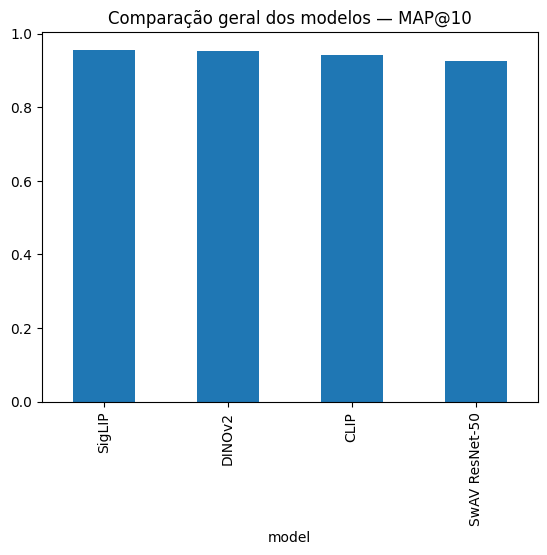

In [27]:
results_df.plot(
    x="model",
    y="MAP@10",
    kind="bar",
    legend=False,
    title="Comparação geral dos modelos — MAP@10"
)

###Etapa 6: Comparação de desempenho por classe

In [28]:
def evaluate_mapk_per_class(valid_queries, gallery, predictions_df, k=10):
    gallery_label_map = dict(zip(gallery["gallery_id"], gallery["label_name"]))
    query_label_map = dict(zip(valid_queries["query_id"], valid_queries["label_name"]))

    results = []

    for _, row in predictions_df.iterrows():
        query_id = row["query_id"]
        predicted_gallery_ids = row["predictions"].split()[:k]

        actual_label = query_label_map[query_id]

        predicted_labels = [
            gallery_label_map[g_id]
            for g_id in predicted_gallery_ids
        ]

        ap = apk(actual_label, predicted_labels, k=k)

        results.append({
            "query_id": query_id,
            "label": actual_label,
            "ap": ap
        })

    results_df = pd.DataFrame(results)

    # média por classe
    per_class = results_df.groupby("label")["ap"].mean().reset_index()
    per_class = per_class.rename(columns={"ap": "MAP@10"})

    return per_class

In [29]:
per_class_results = []

models_predictions = {
    "DINOv2": dinov2_valid_predictions,
    "CLIP": clip_valid_predictions,
    #"ConvNeXt-Tiny": convnext_valid_predictions,
    "SwAV ResNet-50": swav_valid_predictions,
    "SigLIP": siglip_valid_predictions,
}

for model_name, predictions_df in models_predictions.items():
    per_class_df = evaluate_mapk_per_class(
        valid_queries,
        gallery,
        predictions_df,
        k=10
    )

    per_class_df["model"] = model_name

    per_class_results.append(per_class_df)

per_class_results_df = pd.concat(per_class_results)

display(per_class_results_df.head())

,label,MAP@10,model
0,Damaged concrete structures,0.986979,DINOv2
1,DamagedElectricalPoles,0.890215,DINOv2
2,DamagedRoadSigns,0.910435,DINOv2
3,DeadAnimalsPollution,0.749950,DINOv2
4,FallenTrees,0.850827,DINOv2


In [30]:
pivot_df = per_class_results_df.pivot(
    index="label",
    columns="model",
    values="MAP@10"
)

display(pivot_df)

model,CLIP,DINOv2,SigLIP,SwAV ResNet-50
label,,,,
Damaged concrete structures,0.996517,0.986979,0.997093,0.990177
DamagedElectricalPoles,0.843418,0.890215,0.914973,0.835908
DamagedRoadSigns,0.714376,0.910435,0.780655,0.769843
DeadAnimalsPollution,0.777981,0.749950,0.873750,0.471042
FallenTrees,0.810766,0.850827,0.838125,0.701392
Garbage,0.961713,0.973228,0.978001,0.935551
Graffitti,0.786132,0.787568,0.763088,0.768138
IllegalParking,0.064583,0.839444,0.445833,0.100000
Potholes and RoadCracks,0.982601,0.985896,0.989318,0.982476


<Axes: title={'center': 'Desempenho por classe (MAP@10)'}, xlabel='label'>

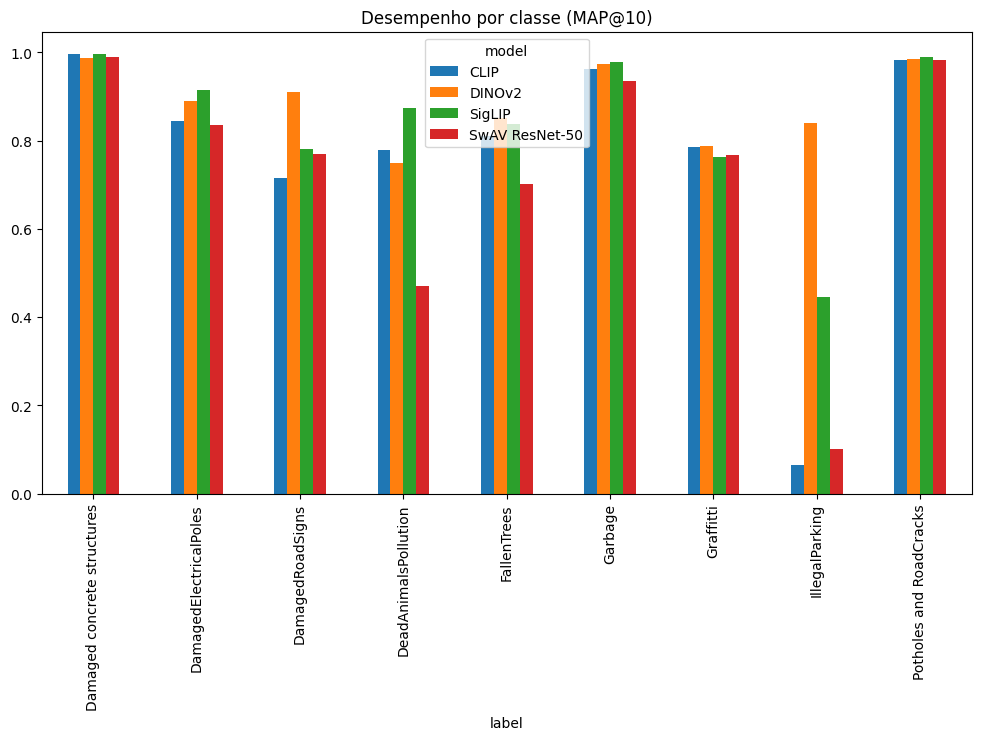

In [31]:
pivot_df.plot(
    kind="bar",
    figsize=(12, 6),
    title="Desempenho por classe (MAP@10)"
)

In [32]:
siglip_gallery_ids, siglip_gallery_embeddings = load_embeddings(
    embeddings_dir / "siglip_gallery_embeddings.npz"
)

siglip_test_query_ids, siglip_test_query_embeddings = load_embeddings(
    embeddings_dir / "siglip_test_query_embeddings.npz"
)

siglip_test_predictions = generate_retrieval_predictions(
    query_ids=siglip_test_query_ids,
    query_embeddings=siglip_test_query_embeddings,
    gallery_ids=siglip_gallery_ids,
    gallery_embeddings=siglip_gallery_embeddings,
    k=10
)

# Garante a ordem do test_queries.csv
siglip_test_predictions = test_queries[["query_id"]].merge(
    siglip_test_predictions,
    on="query_id",
    how="left"
)

siglip_test_predictions.to_csv(
    "submission_siglip.csv",
    index=False
)

display(siglip_test_predictions.head())
print(siglip_test_predictions.shape)

,query_id,predictions
0,t_000000,g_000001 g_000033 g_000074 g_000204 g_000161 g...
1,t_000001,g_000132 g_000085 g_000074 g_000032 g_000080 g...
2,t_000002,g_000027 g_000062 g_000078 g_001470 g_000144 g...
3,t_000003,g_001470 g_000002 g_000142 g_000141 g_000144 g...
4,t_000004,g_000053 g_000020 g_001389 g_000210 g_000141 g...


(3402, 2)


In [33]:
clip_gallery_ids, clip_gallery_embeddings = load_embeddings(
    embeddings_dir / "clip_gallery_embeddings.npz"
)

clip_test_query_ids, clip_test_query_embeddings = load_embeddings(
    embeddings_dir / "clip_test_query_embeddings.npz"
)

clip_test_predictions = generate_retrieval_predictions(
    query_ids=clip_test_query_ids,
    query_embeddings=clip_test_query_embeddings,
    gallery_ids=clip_gallery_ids,
    gallery_embeddings=clip_gallery_embeddings,
    k=10
)

# Garante a ordem do test_queries.csv
clip_test_predictions = test_queries[["query_id"]].merge(
    clip_test_predictions,
    on="query_id",
    how="left"
)

clip_test_predictions.to_csv(
    "submission_clip.csv",
    index=False
)

display(clip_test_predictions.head())
print(clip_test_predictions.shape)

,query_id,predictions
0,t_000000,g_000204 g_001390 g_001465 g_000029 g_000045 g...
1,t_000001,g_000002 g_000085 g_000080 g_000138 g_000032 g...
2,t_000002,g_000029 g_000028 g_000086 g_000157 g_000166 g...
3,t_000003,g_000035 g_000002 g_000153 g_000157 g_000032 g...
4,t_000004,g_015137 g_000138 g_000064 g_000020 g_000085 g...


(3402, 2)


In [1]:
import numpy as np
import pandas as pd

In [2]:
def ensemble_predictions_two_models(
    query_ids,
    gallery_ids,
    query_emb_a,
    gallery_emb_a,
    query_emb_b,
    gallery_emb_b,
    alpha=0.65,
    k=10
):

    sim_a = query_emb_a @ gallery_emb_a.T
    sim_b = query_emb_b @ gallery_emb_b.T
    final_sim = alpha * sim_a + (1 - alpha) * sim_b
    topk_indices = np.argsort(-final_sim, axis=1)[:, :k]
    predictions = []

    for i, query_id in enumerate(query_ids):
        top_gallery_ids = gallery_ids[topk_indices[i]]
        predictions.append({
            "query_id": query_id,
            "predictions": " ".join(top_gallery_ids)})

    return pd.DataFrame(predictions)

In [14]:
siglip_gallery_ids, siglip_gallery_embeddings = load_embeddings(
    embeddings_dir / "siglip_gallery_embeddings.npz")

siglip_valid_query_ids, siglip_valid_query_embeddings = load_embeddings(
    embeddings_dir / "siglip_valid_query_embeddings.npz")

dinov2_gallery_ids, dinov2_gallery_embeddings = load_embeddings(
    embeddings_dir / "dinov2_gallery_embeddings.npz")

dinov2_valid_query_ids, dinov2_valid_query_embeddings = load_embeddings(
    embeddings_dir / "dinov2_valid_query_embeddings.npz")

In [19]:
ensemble_results = []

for alpha in [0.5, 0.6, 0.7, 0.8, 0.85, 0.9]:
    preds = ensemble_predictions_two_models(
        query_ids=siglip_valid_query_ids,
        gallery_ids=siglip_gallery_ids,
        query_emb_a=siglip_valid_query_embeddings,
        gallery_emb_a=siglip_gallery_embeddings,
        query_emb_b=dinov2_valid_query_embeddings,
        gallery_emb_b=dinov2_gallery_embeddings,
        alpha=alpha,
        k=10)

    score = evaluate_retrieval_mapk(
        valid_queries=valid_queries,
        gallery=gallery,
        predictions_df=preds,
        k=10)

    ensemble_results.append({
        "ensemble": "SigLIP + DINOv2",
        "alpha_siglip": alpha,
        "alpha_dinov2": 1 - alpha,
        "MAP@10": score})

ensemble_results_df = pd.DataFrame(ensemble_results).sort_values(
    by="MAP@10",
    ascending=False)

display(ensemble_results_df)

,ensemble,alpha_siglip,alpha_dinov2,MAP@10
2,SigLIP + DINOv2,0.70,0.30,0.966599
3,SigLIP + DINOv2,0.80,0.20,0.966516
4,SigLIP + DINOv2,0.85,0.15,0.965767
1,SigLIP + DINOv2,0.60,0.40,0.965240
0,SigLIP + DINOv2,0.50,0.50,0.964093
5,SigLIP + DINOv2,0.90,0.10,0.963779


In [20]:
BEST_ALPHA = ensemble_results_df.iloc[0]["alpha_siglip"]

siglip_test_query_ids, siglip_test_query_embeddings = load_embeddings(
    embeddings_dir / "siglip_test_query_embeddings.npz")

dinov2_test_query_ids, dinov2_test_query_embeddings = load_embeddings(
    embeddings_dir / "dinov2_test_query_embeddings.npz")

ensemble_test_predictions = ensemble_predictions_two_models(
    query_ids=siglip_test_query_ids,
    gallery_ids=siglip_gallery_ids,
    query_emb_a=siglip_test_query_embeddings,
    gallery_emb_a=siglip_gallery_embeddings,
    query_emb_b=dinov2_test_query_embeddings,
    gallery_emb_b=dinov2_gallery_embeddings,
    alpha=BEST_ALPHA,
    k=10)

ensemble_test_predictions = test_queries[["query_id"]].merge(
    ensemble_test_predictions,
    on="query_id",
    how="left")

ensemble_test_predictions.to_csv(
    "submission_ensemble_siglip_dinov2.csv",
    index=False)

display(ensemble_test_predictions.head())
print("BEST_ALPHA:", BEST_ALPHA)
print(ensemble_test_predictions.shape)

,query_id,predictions
0,t_000000,g_000001 g_000033 g_000142 g_000078 g_000158 g...
1,t_000001,g_000032 g_000035 g_000043 g_000139 g_000033 g...
2,t_000002,g_000078 g_000144 g_000014 g_000147 g_000033 g...
3,t_000003,g_000142 g_000002 g_000033 g_000078 g_000073 g...
4,t_000004,g_000020 g_000141 g_001377 g_000122 g_001389 g...


BEST_ALPHA: 0.7
(3402, 2)


In [21]:
def ensemble_similarity_matrix(
    query_emb_a,
    gallery_emb_a,
    query_emb_b,
    gallery_emb_b,
    alpha=0.7):
    sim_a = query_emb_a @ gallery_emb_a.T
    sim_b = query_emb_b @ gallery_emb_b.T

    return alpha * sim_a + (1 - alpha) * sim_b


In [22]:
def generate_pseudoclass_rerank_predictions(
    query_ids,
    gallery_ids,
    similarity_matrix,
    gallery,
    pseudo_top_k=20,
    rerank_pool_k=50,
    final_k=10,
    min_confidence=0.7):
    gallery_label_map = dict(zip(gallery["gallery_id"], gallery["label_name"]))

    predictions = []

    for i, query_id in enumerate(query_ids):
        scores = similarity_matrix[i]

        ranked_idx = np.argsort(-scores)
        ranked_gallery_ids = gallery_ids[ranked_idx]

        # Top-20 para estimar pseudo-classe
        pseudo_pool = ranked_gallery_ids[:pseudo_top_k]
        pseudo_labels = [gallery_label_map[g_id] for g_id in pseudo_pool]

        label_counts = pd.Series(pseudo_labels).value_counts()
        pseudo_class = label_counts.index[0]
        confidence = label_counts.iloc[0] / pseudo_top_k

        # Top-50 onde o re-ranking será aplicado
        rerank_pool = ranked_gallery_ids[:rerank_pool_k]

        if confidence >= min_confidence:
            same_class = [
                g_id for g_id in rerank_pool
                if gallery_label_map[g_id] == pseudo_class
            ]

            other_class = [
                g_id for g_id in rerank_pool
                if gallery_label_map[g_id] != pseudo_class
            ]

            reranked_gallery_ids = same_class + other_class

        else:
            reranked_gallery_ids = list(rerank_pool)

        final_gallery_ids = reranked_gallery_ids[:final_k]

        predictions.append({
            "query_id": query_id,
            "predictions": " ".join(final_gallery_ids),
            "pseudo_class": pseudo_class,
            "confidence": confidence,
            "rerank_applied": confidence >= min_confidence
        })

    return pd.DataFrame(predictions)

In [23]:
BEST_ALPHA = ensemble_results_df.iloc[0]["alpha_siglip"]

valid_similarity_matrix = ensemble_similarity_matrix(
    query_emb_a=siglip_valid_query_embeddings,
    gallery_emb_a=siglip_gallery_embeddings,
    query_emb_b=dinov2_valid_query_embeddings,
    gallery_emb_b=dinov2_gallery_embeddings,
    alpha=BEST_ALPHA
)

rerank_results = []

thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

for threshold in thresholds:
    preds_with_info = generate_pseudoclass_rerank_predictions(
        query_ids=siglip_valid_query_ids,
        gallery_ids=siglip_gallery_ids,
        similarity_matrix=valid_similarity_matrix,
        gallery=gallery,
        pseudo_top_k=20,
        rerank_pool_k=50,
        final_k=10,
        min_confidence=threshold
    )

    preds = preds_with_info[["query_id", "predictions"]]

    score = evaluate_retrieval_mapk(
        valid_queries=valid_queries,
        gallery=gallery,
        predictions_df=preds,
        k=10
    )

    rerank_results.append({
        "min_confidence": threshold,
        "MAP@10": score,
        "rerank_applied_rate": preds_with_info["rerank_applied"].mean()
    })

rerank_results_df = pd.DataFrame(rerank_results).sort_values(
    by="MAP@10",
    ascending=False
)

display(rerank_results_df)

,min_confidence,MAP@10,rerank_applied_rate
0,0.50,0.978264,0.997086
1,0.60,0.976907,0.988609
2,0.70,0.975422,0.977219
3,0.80,0.972116,0.957881
4,0.90,0.969859,0.936159
5,0.95,0.968626,0.918675


In [24]:
BEST_THRESHOLD = rerank_results_df.iloc[0]["min_confidence"]

test_similarity_matrix = ensemble_similarity_matrix(
    query_emb_a=siglip_test_query_embeddings,
    gallery_emb_a=siglip_gallery_embeddings,
    query_emb_b=dinov2_test_query_embeddings,
    gallery_emb_b=dinov2_gallery_embeddings,
    alpha=BEST_ALPHA
)

ensemble_rerank_test_predictions_info = generate_pseudoclass_rerank_predictions(
    query_ids=siglip_test_query_ids,
    gallery_ids=siglip_gallery_ids,
    similarity_matrix=test_similarity_matrix,
    gallery=gallery,
    pseudo_top_k=20,
    rerank_pool_k=50,
    final_k=10,
    min_confidence=BEST_THRESHOLD
)

ensemble_rerank_test_predictions = ensemble_rerank_test_predictions_info[
    ["query_id", "predictions"]
]

ensemble_rerank_test_predictions = test_queries[["query_id"]].merge(
    ensemble_rerank_test_predictions,
    on="query_id",
    how="left"
)

ensemble_rerank_test_predictions.to_csv(
    "submission_ensemble_siglip_dinov2_pseudoclass_rerank.csv",
    index=False
)

display(ensemble_rerank_test_predictions.head())
print("BEST_ALPHA:", BEST_ALPHA)
print("BEST_THRESHOLD:", BEST_THRESHOLD)
print(ensemble_rerank_test_predictions.shape)

,query_id,predictions
0,t_000000,g_000001 g_000033 g_000142 g_000078 g_000158 g...
1,t_000001,g_000032 g_000035 g_000043 g_000139 g_000033 g...
2,t_000002,g_000078 g_000144 g_000014 g_000147 g_000033 g...
3,t_000003,g_000142 g_000002 g_000033 g_000078 g_000073 g...
4,t_000004,g_000020 g_000141 g_001377 g_000122 g_001389 g...


BEST_ALPHA: 0.7
BEST_THRESHOLD: 0.5
(3402, 2)


In [ ]:
# 1. Ensemble SigLIP + DINOv2
# 2. Estima pseudo-classe pelo top-N
# 3. Se confiança >= threshold:
#       adiciona um bônus suave no score das imagens da pseudo-classe
# 4. Reordena top-M
# 5. Retorna top-10

In [25]:
def generate_pseudoclass_boost_predictions(
    query_ids,
    gallery_ids,
    similarity_matrix,
    gallery,
    pseudo_top_k=20,
    rerank_pool_k=50,
    final_k=10,
    min_confidence=0.7,
    bonus=0.02
):
    gallery_label_map = dict(zip(gallery["gallery_id"], gallery["label_name"]))

    predictions = []

    for i, query_id in enumerate(query_ids):
        scores = similarity_matrix[i]

        ranked_idx = np.argsort(-scores)
        pool_idx = ranked_idx[:rerank_pool_k]
        pool_gallery_ids = gallery_ids[pool_idx]
        pool_scores = scores[pool_idx].copy()

        pseudo_gallery_ids = gallery_ids[ranked_idx[:pseudo_top_k]]
        pseudo_labels = [gallery_label_map[g_id] for g_id in pseudo_gallery_ids]

        label_counts = pd.Series(pseudo_labels).value_counts()
        pseudo_class = label_counts.index[0]
        confidence = label_counts.iloc[0] / pseudo_top_k

        if confidence >= min_confidence:
            for j, g_id in enumerate(pool_gallery_ids):
                if gallery_label_map[g_id] == pseudo_class:
                    pool_scores[j] += bonus

        reranked_order = np.argsort(-pool_scores)
        final_gallery_ids = pool_gallery_ids[reranked_order][:final_k]

        predictions.append({
            "query_id": query_id,
            "predictions": " ".join(final_gallery_ids),
            "pseudo_class": pseudo_class,
            "confidence": confidence,
            "boost_applied": confidence >= min_confidence
        })

    return pd.DataFrame(predictions)

In [29]:
BEST_ALPHA = ensemble_results_df.iloc[0]["alpha_siglip"]

valid_similarity_matrix = ensemble_similarity_matrix(
    query_emb_a=siglip_valid_query_embeddings,
    gallery_emb_a=siglip_gallery_embeddings,
    query_emb_b=dinov2_valid_query_embeddings,
    gallery_emb_b=dinov2_gallery_embeddings,
    alpha=BEST_ALPHA
)

pseudo_top_ks = [15, 25]
rerank_pool_ks = [20, 25, 30]
min_confidences = [0.25, 0.35, 0.45]
bonuses = [0.03, 0.05, 0.07]

boost_results = []

for pseudo_top_k in pseudo_top_ks:
    for rerank_pool_k in rerank_pool_ks:
        for min_confidence in min_confidences:
            for bonus in bonuses:

                preds_info = generate_pseudoclass_boost_predictions(
                    query_ids=siglip_valid_query_ids,
                    gallery_ids=siglip_gallery_ids,
                    similarity_matrix=valid_similarity_matrix,
                    gallery=gallery,
                    pseudo_top_k=pseudo_top_k,
                    rerank_pool_k=rerank_pool_k,
                    final_k=10,
                    min_confidence=min_confidence,
                    bonus=bonus
                )

                preds = preds_info[["query_id", "predictions"]]

                score = evaluate_retrieval_mapk(
                    valid_queries=valid_queries,
                    gallery=gallery,
                    predictions_df=preds,
                    k=10
                )

                boost_results.append({
                    "pseudo_top_k": pseudo_top_k,
                    "rerank_pool_k": rerank_pool_k,
                    "min_confidence": min_confidence,
                    "bonus": bonus,
                    "MAP@10": score,
                    "boost_applied_rate": preds_info["boost_applied"].mean()
                })

boost_results_df = pd.DataFrame(boost_results).sort_values(
    by="MAP@10",
    ascending=False
)

display(boost_results_df.head(20))

,pseudo_top_k,rerank_pool_k,min_confidence,bonus,MAP@10,boost_applied_rate
20,15,30,0.25,0.07,0.980657,1.000000
11,15,25,0.25,0.07,0.980604,1.000000
23,15,30,0.35,0.07,0.980493,0.999735
14,15,25,0.35,0.07,0.980467,0.999735
19,15,30,0.25,0.05,0.980352,1.000000
10,15,25,0.25,0.05,0.980325,1.000000
2,15,20,0.25,0.07,0.980218,1.000000
22,15,30,0.35,0.05,0.980188,0.999735
13,15,25,0.35,0.05,0.980188,0.999735
5,15,20,0.35,0.07,0.980133,0.999735


In [30]:
best_cfg = boost_results_df.iloc[0]

BEST_PSEUDO_TOP_K = int(best_cfg["pseudo_top_k"])
BEST_RERANK_POOL_K = int(best_cfg["rerank_pool_k"])
BEST_MIN_CONFIDENCE = float(best_cfg["min_confidence"])
BEST_BONUS = float(best_cfg["bonus"])

test_similarity_matrix = ensemble_similarity_matrix(
    query_emb_a=siglip_test_query_embeddings,
    gallery_emb_a=siglip_gallery_embeddings,
    query_emb_b=dinov2_test_query_embeddings,
    gallery_emb_b=dinov2_gallery_embeddings,
    alpha=BEST_ALPHA
)

boost_test_predictions_info = generate_pseudoclass_boost_predictions(
    query_ids=siglip_test_query_ids,
    gallery_ids=siglip_gallery_ids,
    similarity_matrix=test_similarity_matrix,
    gallery=gallery,
    pseudo_top_k=BEST_PSEUDO_TOP_K,
    rerank_pool_k=BEST_RERANK_POOL_K,
    final_k=10,
    min_confidence=BEST_MIN_CONFIDENCE,
    bonus=BEST_BONUS
)

boost_test_predictions = boost_test_predictions_info[["query_id", "predictions"]]

boost_test_predictions = test_queries[["query_id"]].merge(
    boost_test_predictions,
    on="query_id",
    how="left"
)

boost_test_predictions.to_csv(
    "submission_ensemble_siglip_dinov2_pseudoclass_boost_2.csv",
    index=False
)

display(boost_test_predictions.head())

print("BEST_ALPHA:", BEST_ALPHA)
print("BEST_PSEUDO_TOP_K:", BEST_PSEUDO_TOP_K)
print("BEST_RERANK_POOL_K:", BEST_RERANK_POOL_K)
print("BEST_MIN_CONFIDENCE:", BEST_MIN_CONFIDENCE)
print("BEST_BONUS:", BEST_BONUS)
print(boost_test_predictions.shape)

,query_id,predictions
0,t_000000,g_000001 g_000033 g_000142 g_000078 g_000158 g...
1,t_000001,g_000032 g_000035 g_000043 g_000139 g_000033 g...
2,t_000002,g_000078 g_000144 g_000014 g_000147 g_000033 g...
3,t_000003,g_000142 g_000002 g_000033 g_000078 g_000073 g...
4,t_000004,g_000020 g_000141 g_001377 g_000122 g_001389 g...


BEST_ALPHA: 0.7
BEST_PSEUDO_TOP_K: 15
BEST_RERANK_POOL_K: 30
BEST_MIN_CONFIDENCE: 0.25
BEST_BONUS: 0.07
(3402, 2)
